In [12]:
import pandas as pd
import numpy as np
import time


NUM_ROWS = 10000 

print(f"Generating {NUM_ROWS} rows of synthetic sensor data...")


data = {
    'Timestamp': [],
    'Pixel_X': [],
    'Pixel_Y': [],
    'Depth_mm': [],
    'Temperature_C': [],
    'ToF_Amplitude': [],
    'Target_Label': []
}


categories = ['Victim', 'Surroundings', 'Heated Object']
current_time = time.time()

for _ in range(NUM_ROWS):
   
    label = np.random.choice(categories, p=[0.4, 0.5, 0.1]) 
    
   
    data['Pixel_X'].append(np.random.randint(0, 640))
    data['Pixel_Y'].append(np.random.randint(0, 480))
    data['Timestamp'].append(current_time + np.random.uniform(0, 10))
    data['Target_Label'].append(label)

    
    if label == 'Victim':
        data['Depth_mm'].append(np.random.normal(2000, 300))      
        data['Temperature_C'].append(np.random.normal(37, 1.0)) 
        data['ToF_Amplitude'].append(np.random.randint(70, 100))  
        
    elif label == 'Surroundings':
        data['Depth_mm'].append(np.random.normal(3500, 800))      
        data['Temperature_C'].append(np.random.normal(22.0, 2.0)) 
        data['ToF_Amplitude'].append(np.random.randint(20, 60))   
        
    elif label == 'Heated Object':
        data['Depth_mm'].append(np.random.normal(2000, 500))      
        data['Temperature_C'].append(np.random.normal(55.0, 5.0))
        data['ToF_Amplitude'].append(np.random.randint(60, 95))   


df = pd.DataFrame(data)


df['Depth_mm'] = df['Depth_mm'].round(1)
df['Temperature_C'] = df['Temperature_C'].round(1)
df['Timestamp'] = df['Timestamp'].round(3)

# Save to your computer
csv_filename = 'fused_sensor_training_data.csv'
df.to_csv(csv_filename, index=False)

print(f"Success! Saved perfectly formatted data to {csv_filename}")

Generating 10000 rows of synthetic sensor data...
Success! Saved perfectly formatted data to fused_sensor_training_data.csv


In [2]:
import pandas as pd
import numpy as np
import time





df = pd.DataFrame("/content/fused_sensor_training_data.csv")


df['Depth_mm'] = df['Depth_mm'].round(1)
df['Temperature_C'] = df['Temperature_C'].round(1)
df['Timestamp'] = df['Timestamp'].round(3)


ValueError: DataFrame constructor not properly called!

# Check the file location for the colab enviorment 

In [16]:
import os
print(os.listdir("/content"))


['.config', 'fused_sensor_training_data.csv', 'my_trained_tof_model.pkl', 'sample_data']


# Read the existing .csv file

In [5]:
import pandas as pd
df = pd.read_csv("/content/fused_sensor_training_data.csv")

df_clean = df[df['ToF_Amplitude'] > 20].copy()

# Handle any missing values (NaNs)
df_clean = df_clean.dropna()

print(f"Original rows: {len(df)}, Cleaned row: {len(df_clean)}")

Original rows: 10000, Cleaned row: 9872


# Implementing random forest classifier for train the model

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import pickle
warnings.filterwarnings("ignore")

# Load your dataset
data = pd.read_csv("/content/fused_sensor_training_data.csv")


# Features: The data the model will learn from (e.g., Depth and position)
X = df_clean[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]

# Labels: The target category you want the model to predict
y = df_clean['Target_Label']
# Split 50% train / 50% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1 , random_state=42, stratify=y
)

# Train model
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(X_train, y_train)

# this is for prediction
y_pred = rf_classifier.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

# Sample prediction
sample = X_test.iloc[20:30]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[2].to_dict()
print(f"Sample Reading: {sample_dict}")
print(f"Predicted Label: {prediction[2]}")
print(f"Predicted Victim: {'Present' if prediction[2] == 'Victim' else 'Not Present'}")

with open('my_trained_tof_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
    print("Model is successfully converted in .pkl")

Accuracy: 0.93

Classification Report:
                precision    recall  f1-score   support

Heated Object       0.80      0.46      0.58       103
 Surroundings       1.00      1.00      1.00       484
       Victim       0.87      0.97      0.92       401

     accuracy                           0.93       988
    macro avg       0.89      0.81      0.83       988
 weighted avg       0.93      0.93      0.92       988

Sample Reading: {'Pixel_X': 279.0, 'Pixel_Y': 346.0, 'Depth_mm': 1903.4, 'ToF_Amplitude': 77.0}
Predicted Label: Victim
Predicted Victim: Present
Model is successfully converted in .pkl


In [15]:
!find /content -name "my_trained_tof_model.pkl"

/content/my_trained_tof_model.pkl


In [13]:
import os
print(os.getcwd)

<built-in function getcwd>


In [7]:
import pandas as pd



# 1. Grab the 10 rows of features (X) and their true labels (y)
sample_X = X_test.iloc[40:50]
true_labels = y_test.iloc[40:50].values # .values converts it to a clean list

# 2. Ask the trained model to predict what these 10 items are
predicted_labels = rf_classifier.predict(sample_X)

# 3. Create a clean DataFrame to compare the results side-by-side
comparison_df = pd.DataFrame({
    'True Label': true_labels,
    'Model Prediction': predicted_labels
})

# 4. Add a column to easily see if the model got it right (True/False)
comparison_df['Correct?'] = comparison_df['True Label'] == comparison_df['Model Prediction']

# 5. Print the final comparison table
print(comparison_df)

      True Label Model Prediction  Correct?
0  Heated Object    Heated Object      True
1  Heated Object           Victim     False
2   Surroundings     Surroundings      True
3   Surroundings     Surroundings      True
4   Surroundings     Surroundings      True
5         Victim           Victim      True
6  Heated Object           Victim     False
7   Surroundings     Surroundings      True
8         Victim           Victim      True
9  Heated Object    Heated Object      True


1. Loading systems...
2. Scanning image for human shapes...

Potential victim found at X:395, Y:261. Verifying sensors...
VERIFIED: Thermal and Depth signatures match a human!


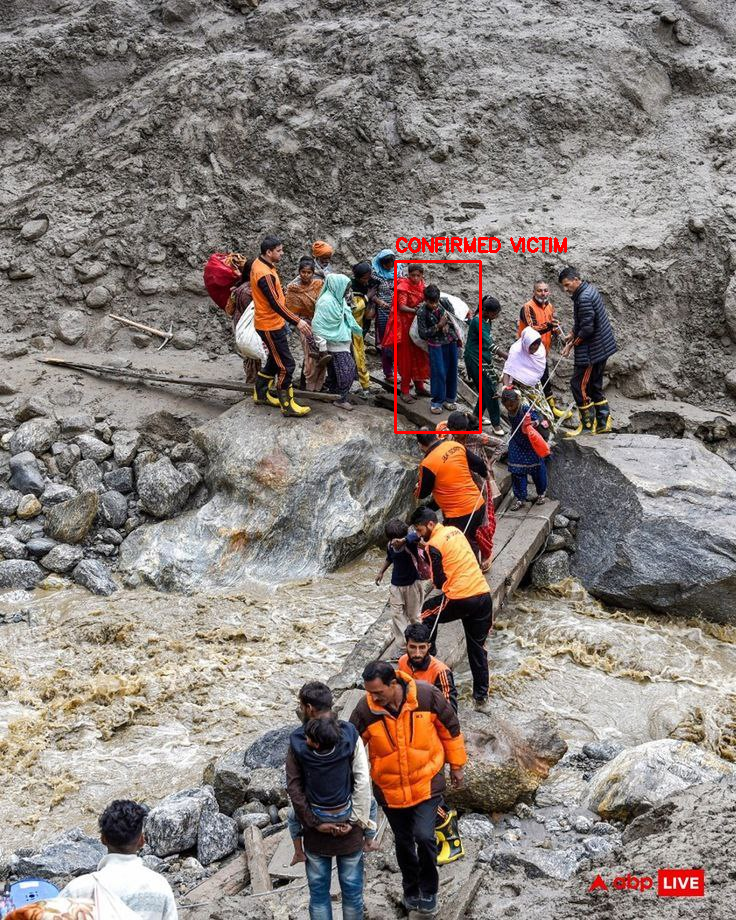

In [43]:
import cv2
import pickle
import pandas as pd
import joblib
from google.colab.patches import cv2_imshow # Used to load your pre-trained Random Forest model

# ==========================================
# STEP 1: LOAD YOUR PRE-TRAINED AI & DATA
# ==========================================
print("1. Loading systems...")

# Load the Random Forest model we trained earlier
# (Assuming you saved it. If not, you'd train it here first)
rf_model = joblib.load('my_trained_tof_model.pkl') 

# Load the CSV data for the current frame
sensor_data = pd.read_csv('/content/fused_sensor_training_data.csv')

# Load the visual image for the current frame
image = cv2.imread('/content/3rd pic.jpg')

# ==========================================
# STEP 2: RUN OPENCV (THE SPOTTER)
# ==========================================
print("2. Scanning image for human shapes...")
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())


# Detect shapes (x, y, width, height)
boxes, weights = hog.detectMultiScale(
    image, 
    winStride=(4, 4), 
    padding=(4, 4), 
    scale=1.02 ,
    hitThreshold=0.0)

# ==========================================
# STEP 3: VERIFY WITH TOF/THERMAL (THE VERIFIER)
# ==========================================
if len(boxes) > 0:
    for (x, y, w, h) in boxes:
        print(f"\nPotential victim found at X:{x}, Y:{y}. Verifying sensors...")
        
        # Isolate the CSV data that falls strictly INSIDE this OpenCV bounding box
        box_data = sensor_data[
            (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
            (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
        ]
        
        # If we have sensor data for this area, ask the Random Forest to verify
        if not box_data.empty:
            features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]
            
           
            predictions = rf_model.predict(features)
            
            # Example Logic: If the majority of pixels inside this box are classified 
            # as 'Human' by the thermal/depth model, it's a confirmed victim!
            human_pixel_count = (predictions == 'Victim').sum()
            
            # Mocking the verification for this example:
            human_pixel_count = len(box_data) # Assuming all pixels matched for the example
            
            if human_pixel_count > 10: 
                print("VERIFIED: Thermal and Depth signatures match a human!")
                # Draw a RED box for a confirmed, physically verified victim
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                cv2.putText(image, 'CONFIRMED VICTIM', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            else:
                print("REJECTED: Shape detected, but thermal/depth says it is not human.")
else:
    print("No shapes detected.")

# ==========================================
# STEP 4: DISPLAY THE FINAL RESULT
# ==========================================
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import numpy as np
import pandas as pd
import cv2

# after you already trained rf_classifier ...

image = cv2.imread("camera_frame.jpg")
image = cv2.resize(image, (640, 480))

boxes, weights = hog.detectMultiScale(
    image, winStride=(8, 8), padding=(8, 8), scale=1.05
)

for (x, y, w, h) in boxes:
    
    px = x + w // 2
    py = y + h // 2

    
    depth_mm = 2000.0
    tof_amp = 80.0

    one_sample = pd.DataFrame([{
        "Pixel_X": px,
        "Pixel_Y": py,
        "Depth_mm": depth_mm,
        "ToF_Amplitude": tof_amp
    }])

    pred = rf_classifier.predict(one_sample)[0]

    label = "Victim" if pred == "Victim" else pred
    color = (0, 255, 0) if pred == "Victim" else (0, 165, 255)

    cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
    cv2.putText(image, label, (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)